# One-call 3-D maps and exporting a scene

- `quickmap(data, backend='3d')` builds a whole `Scene3D` from one call, dispatching by input: a **raster**
  becomes `terrain`, a **point** `FeatureCollection` a `point_cloud`, a **polygon** one `extruded_polygons`.
- A built scene exports via `save()` (suffix picks the format), `screenshot()` (PNG / RGB array) and
  `export_html()` (a self-contained interactive page).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from digitalearth.base.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
from digitalearth import quickmap
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

## `quickmap(backend='3d')` — a raster becomes terrain

quickmap returned: Scene3D | layers: 1


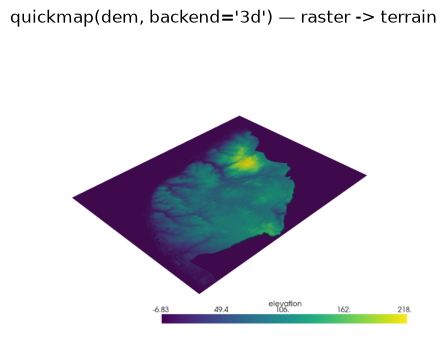

In [2]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = quickmap(dem, backend='3d')
print('quickmap returned:', type(scene).__name__, '| layers:', len(scene.layers))
show(scene, "quickmap(dem, backend='3d') — raster -> terrain")
scene.close()

## `quickmap(backend='3d')` — points become a point cloud, polygons extrude

C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\viz3d\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


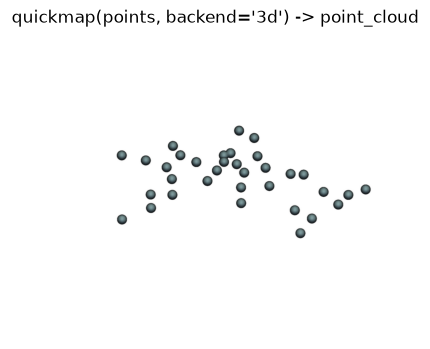

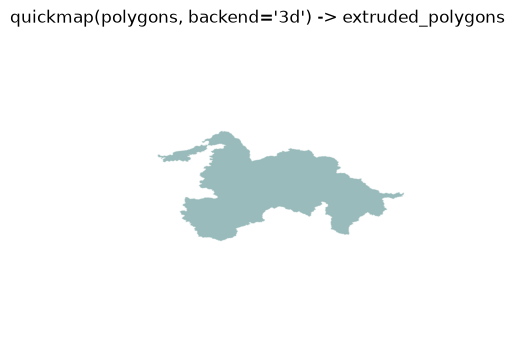

In [3]:
gauges = FeatureCollection.read_file(str(DATA / 'rhine_gauges.geojson'))
scene = quickmap(gauges, backend='3d', size=55.0)
scene.view('isometric')
show(scene, "quickmap(points, backend='3d') -> point_cloud")
scene.close()

basin = FeatureCollection.read_file(str(DATA / 'rhine_basin.geojson'))
scene = quickmap(basin, backend='3d')
show(scene, "quickmap(polygons, backend='3d') -> extruded_polygons")
scene.close()

## Export — `save()`, `screenshot()`, `export_html()`

The suffix picks the writer: `.png` → screenshot, `.html` → interactive page, `.gltf` → a 3-D model.

In [4]:
import tempfile, os
tmp = Path(tempfile.mkdtemp())
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')

frame = scene.screenshot(str(tmp / 'terrain.png'))   # writes PNG and returns the RGB array
html = scene.save(str(tmp / 'terrain.html'))          # self-contained interactive page
model = scene.save(str(tmp / 'terrain.gltf'))         # a glTF 3-D model
print('screenshot array :', frame.shape)
print('png  bytes :', os.path.getsize(tmp / 'terrain.png'))
print('html bytes :', os.path.getsize(tmp / 'terrain.html'))
print('gltf bytes :', os.path.getsize(model))
scene.close()

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\three_d\base.py:2138: UserWarning: Plotter contains non-PolyData datasets. These have been overwritten with PolyData surfaces and are internally copies of the original datasets.
  exporter(str(path), **kwargs)


screenshot array : (768, 1024, 3)
png  bytes : 75198
html bytes : 7086362
gltf bytes : 13481760
